Load Dataset

In [ ]:

# Dataset

from google.colab import drive
drive.mount('/content/drive')

import os, zipfile
from pathlib import Path


ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DL assignment/Dataset/MRI_dataset")
TRAIN_DIR = ROOT / "Training"
TEST_DIR  = ROOT / "Testing"

if not ROOT.exists():
    ROOT.mkdir(parents=True, exist_ok=True)
    print("Dataset folder not found locally. Provide dataset zip or Google Drive path!")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset Loader

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.inception_v3.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.inception_v3.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED
)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Class Distribution and Weights

In [ ]:

# Class Distribution and Weights

import numpy as np
from collections import Counter
from sklearn.utils import class_weight

# Distribution
def class_distribution(generator):
    counts = Counter(generator.classes)
    idx_to_class = {v:k for k,v in generator.class_indices.items()}
    return {idx_to_class[k]: counts[k] for k in counts}

print("Train:", class_distribution(train_generator))
print("Val:", class_distribution(val_generator))
print("Test:", class_distribution(test_generator))

# Class weights
y_train = train_generator.classes
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


Train: {'glioma': 1057, 'meningioma': 1072, 'notumor': 1276, 'pituitary': 1166}
Val: {'glioma': 264, 'meningioma': 267, 'notumor': 319, 'pituitary': 291}
Test: {'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}
Class Weights: {0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


Build Transfer Model

In [ ]:
# Build Transfer Model

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,328,356 (85.18 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Callbacks

In [ ]:
# Callbacks

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("inceptionv3_best.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
earlystop  = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1)
reducelr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

Training (Feature Extraction)

In [ ]:

# Train Feature Extractor

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=[checkpoint, earlystop, reducelr],
    class_weight=class_weights_dict
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4887 - loss: 1.2478
Epoch 1: val_accuracy improved from -inf to 0.66521, saving model to inceptionv3_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 1262s 9s/step - accuracy: 0.4897 - loss: 1.2456 - val_accuracy: 0.6652 - val_loss: 0.8702 - learning_rate: 1.0000e-04
Epoch 2/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.7790 - loss: 0.6018
Epoch 2: val_accuracy improved from 0.66521 to 0.67835, saving model to inceptionv3_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 91s 636ms/step - accuracy: 0.7791 - loss: 0.6016 - val_accuracy: 0.6784 - val_loss: 0.7872 - learning_rate: 1.0000e-04
Epoch 3/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8340 - loss: 0.4775
Epoch 3: val_accuracy improved from 0.67835 to 0.72568, saving model to inceptionv3_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 621ms/step - accuracy: 0.8339 - loss: 0.4776 - val_accuracy: 0.7257 - val_loss: 0.7401 - learning_rate: 1.0000e-04
Epoch 4/8
143/143

Fine-Tuning

In [ ]:

# Fine-Tuning

# Unfreeze last N layers
N = 15
for layer in base_model.layers[-N:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, earlystop, reducelr],
    class_weight=class_weights_dict
)


Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8706 - loss: 0.3954
Epoch 1: val_accuracy did not improve from 0.77826
143/143 ━━━━━━━━━━━━━━━━━━━━ 123s 738ms/step - accuracy: 0.8706 - loss: 0.3952 - val_accuracy: 0.7739 - val_loss: 0.5866 - learning_rate: 1.0000e-05
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8820 - loss: 0.3444
Epoch 2: val_accuracy did not improve from 0.77826
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 621ms/step - accuracy: 0.8820 - loss: 0.3444 - val_accuracy: 0.7677 - val_loss: 0.6117 - learning_rate: 1.0000e-05
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8877 - loss: 0.3451
Epoch 3: val_accuracy did not improve from 0.77826
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 620ms/step - accuracy: 0.8877 - loss: 0.3451 - val_accuracy: 0.7765 - val_loss: 0.6058 - learning_rate: 1.0000e-05
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.8910 - loss: 0.3256
Epoch 4: val_accuracy improved from 0.77826 to 0.77914

Model Saving

In [ ]:
# Save final trained model
from google.colab import drive
drive.mount('/content/drive')

final_model_path = "/content/inceptionv3_final.keras"

# Save model locally first (optional but faster)
model.save(final_model_path)
print(f"✅ Model saved locally at: {final_model_path}")

# Copy to Google Drive
import shutil
drive_model_path = "/content/drive/MyDrive/Colab Notebooks/DL assignment/models/inceptionv3_final.keras"
shutil.copy(final_model_path, drive_model_path)
print(f"✅ Model copied to Drive: {drive_model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved locally at: /content/inceptionv3_final.keras
✅ Model copied to Drive: /content/drive/MyDrive/Colab Notebooks/DL assignment/models/inceptionv3_final.keras


Evaluation (Confusion Matrix & Report)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 383s 9s/step - accuracy: 0.8195 - loss: 0.4546
Test Loss: 0.3866, Test Accuracy: 0.8596
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 298ms/step


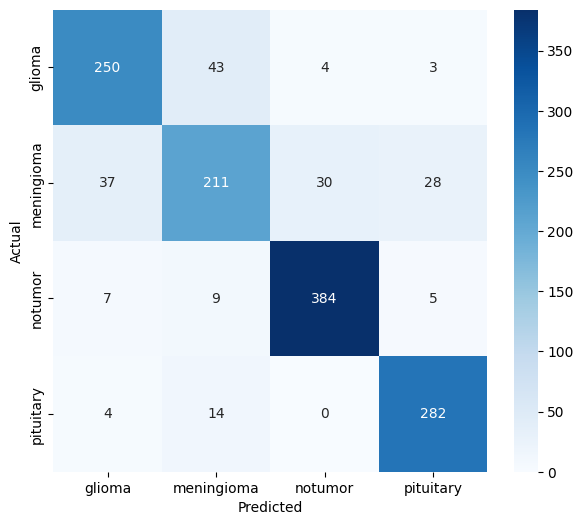

              precision    recall  f1-score   support

      glioma       0.84      0.83      0.84       300
  meningioma       0.76      0.69      0.72       306
     notumor       0.92      0.95      0.93       405
   pituitary       0.89      0.94      0.91       300

    accuracy                           0.86      1311
   macro avg       0.85      0.85      0.85      1311
weighted avg       0.86      0.86      0.86      1311



In [ ]:
# Evaluation on Test Set

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Load best weights
model = load_model("inceptionv3_best.keras")

loss, acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predictions
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
idx_to_class = {v:k for k,v in test_generator.class_indices.items()}

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=idx_to_class.values(),
            yticklabels=idx_to_class.values(),
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(idx_to_class.values())))

Testing (One Image / Batch / Path)

In [ ]:
# Testing Utilities

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load the best model once to avoid repeated loading
try:
    best_model = load_model("inceptionv3_best.keras")
    print("✅ Loaded best model for testing.")
except Exception as e:
    print(f"Error loading best model: {e}")
    best_model = None
    print("Using the current model in the environment. Ensure it is the best model for accurate testing.")


def preprocess_img(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, 0)
    arr = tf.keras.applications.inception_v3.preprocess_input(arr)
    return arr

#  One image
def test_one(index=0):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_one with best model.")
        return

    path = test_generator.filepaths[index]
    arr = preprocess_img(path)
    prob = best_model.predict(arr)
    pred = np.argmax(prob)
    true = test_generator.classes[index]
    print("True:", idx_to_class[true], "| Pred:", idx_to_class[pred], "| Prob:", prob[0][pred])
    display(load_img(path, target_size=IMG_SIZE))

# Mini batch
def test_batch(batch_idx=0):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_batch with best model.")
        return

    X, y = test_generator[batch_idx]
    probs = best_model.predict(X)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(y, axis=1)
    for i in range(min(5, len(X))):
        plt.imshow((X[i] - X[i].min()) / (X[i].max()-X[i].min()))
        plt.axis('off')
        plt.title(f"T:{idx_to_class[trues[i]]} P:{idx_to_class[preds[i]]}")
        plt.show()


# Arbitrary image path
def test_from_path(img_path):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_from_path with best model.")
        return

    arr = preprocess_img(img_path)
    prob = best_model.predict(arr)
    pred = np.argmax(prob)
    print("Pred:", idx_to_class[pred], "| Prob:", prob[0][pred])
    display(load_img(img_path, target_size=IMG_SIZE))

✅ Loaded best model for testing.


Testing for Classes

Saving Tr-gl_0060.jpg to Tr-gl_0060.jpg
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


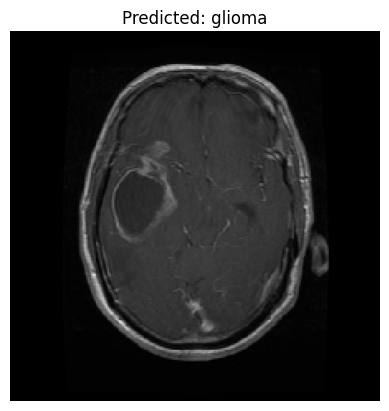

In [ ]:
from google.colab import files
uploaded = files.upload()

from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input
import matplotlib.pyplot as plt

# Load the model
# model_path = "" # You can specify a model path here if needed
model = load_model("inceptionv3_final.keras")

# Get the path of the uploaded file (assuming only one file is uploaded)
for name, data in uploaded.items():
  img_path = "/content/" + name

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict probabilities
pred = model.predict(img_array)
pred_class_idx = np.argmax(pred, axis=1)[0]

# Map index and class name
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
pred_class = idx_to_class[pred_class_idx]

# Display Results
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {pred_class}")
plt.show()